In [8]:
ls

kourier_df_100ms_1core.csv             kourier_df_200ms_1core.csv
kourier_df_100ms_apiserver.csv         kourier_df_200ms_apiserver.csv
kourier_df_100ms_apiserver_pinned.csv  kourier_df_200ms_apiserver_pinned.csv
kourier_df_100ms.csv                   kourier_df_200ms.csv
kourier_df_100ms_hybrid.csv            kourier_df_200ms_hybrid.csv
kourier_df_10ms_1core.csv              kourier_df_50ms_1core.csv
kourier_df_10ms_apiserver.csv          kourier_df_50ms_apiserver.csv
kourier_df_10ms_apiserver_pinned.csv   kourier_df_50ms_apiserver_pinned.csv
kourier_df_10ms.csv                    kourier_df_50ms.csv
kourier_df_10ms_hybrid.csv             kourier_df_50ms_hybrid.csv
kourier_df_1s_1core.csv                kourier_ecdf_overlay.pdf
kourier_df_1s_apiserver_pinned.csv     kourier_ecdf_overlay.png
kourier_df_1s.csv                      Untitled3.ipynb
kourier_df_1s_hybrid.csv


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Delays with data: ['10ms', '50ms', '100ms', '200ms', '1s']
  [OK]   Local / 10ms — 20000 samples, median=312.0ms, p99=22148.1ms
  [OK]   Hybrid / 10ms — 20000 samples, median=261.0ms, p99=22411.4ms
  [OK]   Local 1core / 10ms — 20002 samples, median=279.5ms, p99=23178.5ms
  [OK]   Local / 50ms — 20010 samples, median=87.0ms, p99=7835.8ms
  [OK]   Hybrid / 50ms — 20010 samples, median=96.0ms, p99=6809.8ms
  [OK]   Local 1core / 50ms — 20010 samples, median=86.0ms, p99=7524.8ms
  [OK]   Local / 100ms — 20010 samples, median=80.0ms, p99=6473.7ms
  [OK]   Hybrid / 100ms — 20010 samples, median=91.0ms, p99=6745.5ms
  [OK]   Local 1core / 100ms — 22011 samples, median=81.0ms, p99=5659.1ms
  [OK]   Local / 200ms — 20010 samples, median=78.0ms, p99=5488.2ms
  [OK]   Hybrid / 200ms — 20010 samples, median=85.0ms, p99=5779.5ms
  [OK]   Local 1core / 200ms — 20010 samples, median=87.0ms, p99=5376.9ms
  [OK]   Local / 1s — 20000 samples, median=61.0ms, p99=2853.0ms
  [OK]   Hybrid / 1s — 10000 sam

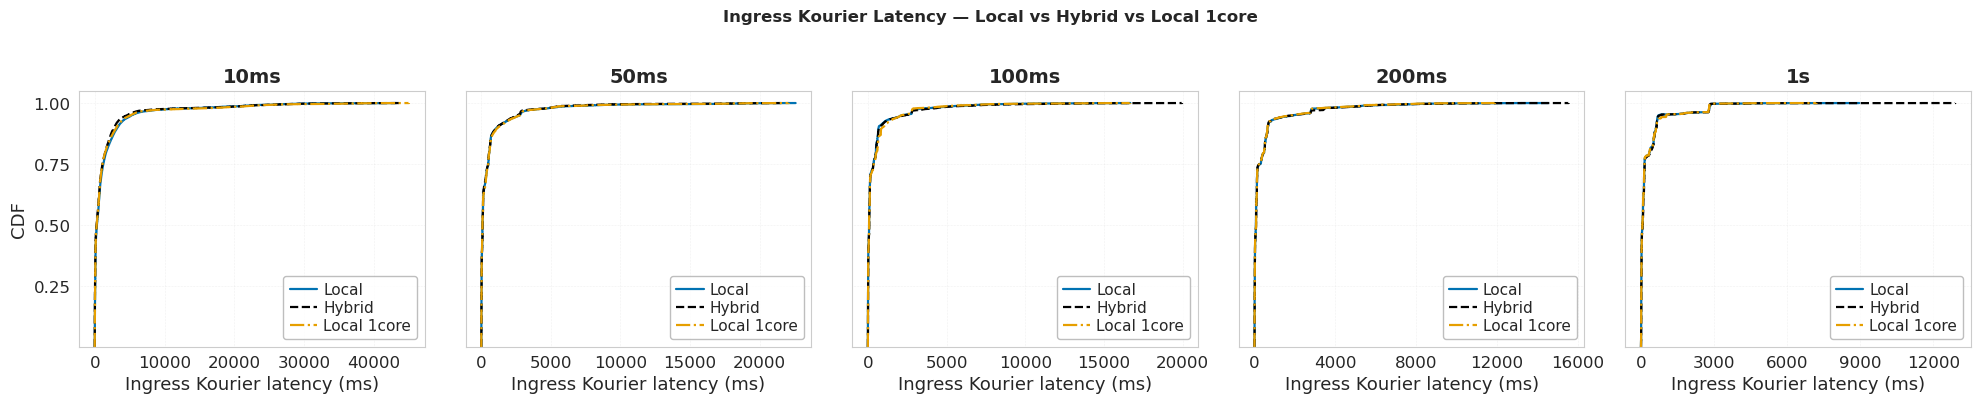

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import os

# ─── STYLE ────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "font.size":          13,
    "axes.titlesize":     14,
    "axes.labelsize":     13,
    "xtick.labelsize":    12,
    "ytick.labelsize":    12,
    "legend.fontsize":    11,
    "legend.framealpha":  0.85,
    "legend.edgecolor":   "0.7",
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "grid.linewidth":     0.4,
    "grid.alpha":         0.4,
    "grid.color":         "0.75",
    "lines.linewidth":    1.6,
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
})

sns.set_style("whitegrid")

# ─── PALETTE ──────────────────────────────────────────────────────────
COLORS     = ["#0072B2", "#000000",  "#E69F00"]   # noir, bleu, orange
LINESTYLES = ["-",       "--",      "-."]
LABELS     = ["Local", "Hybrid", "Local 1core"]

# ─── CONFIG ───────────────────────────────────────────────────────────
DELAYS = ["10ms", "50ms", "100ms", "200ms", "1s"]

DATA_DIR = "."

FILES = {
    "Local": {
        d: os.path.join(DATA_DIR, f"kourier_df_{d}.csv") for d in DELAYS
    },
    "Hybrid": {
        d: os.path.join(DATA_DIR, f"kourier_df_{d}_hybrid.csv") for d in DELAYS
    },
    "Local 1core": {
        d: os.path.join(DATA_DIR, f"kourier_df_{d}_1core.csv") for d in DELAYS
    },
}

MODES = ["Local", "Hybrid", "Local 1core"]

# ─── CHARGEMENT ───────────────────────────────────────────────────────
def load_series(filepath):
    if filepath is None or not os.path.exists(filepath):
        return None
    df = pd.read_csv(filepath)
    return df["duration_ms"].dropna()

# ─── STYLE AXES ───────────────────────────────────────────────────────
def style_ax(ax):
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune='both'))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune='both'))
    ax.tick_params(direction='out', length=3, width=0.6, pad=3)
    ax.grid(True, linestyle=':', linewidth=0.4, color='0.75')

# ─── CHECK AVAILABLE FILES ────────────────────────────────────────────
available_delays = []
for d in DELAYS:
    has_any = any(os.path.exists(FILES[m][d]) for m in MODES)
    if has_any:
        available_delays.append(d)

print(f"Delays with data: {available_delays}")
if not available_delays:
    raise RuntimeError("Aucun fichier trouvé — vérifiez DATA_DIR et les noms de fichiers.")

# ─── FIGURE ───────────────────────────────────────────────────────────
n = len(available_delays)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=True)
if n == 1:
    axes = [axes]

for c, delay in enumerate(available_delays):
    ax = axes[c]

    for i, mode in enumerate(MODES):
        filepath = FILES[mode][delay]
        data = load_series(filepath)
        if data is None:
            print(f"  [SKIP] {mode} / {delay} — file not found")
            continue

        print(f"  [OK]   {mode} / {delay} — {len(data)} samples, median={data.median():.1f}ms, p99={data.quantile(0.99):.1f}ms")

        sns.ecdfplot(
            data=data,
            ax=ax,
            color=COLORS[i],
            linestyle=LINESTYLES[i],
            linewidth=1.6,
            label=LABELS[i],
        )

    ax.set_title(delay, fontweight='bold')
    ax.set_xlabel("Ingress Kourier latency (ms)")

    if c == 0:
        ax.set_ylabel("CDF")

    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.25))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:.2f}"))

    ax.legend(
        loc='lower right',
        handlelength=1.8,
        borderpad=0.4,
        labelspacing=0.2,
        handletextpad=0.4,
    )

    style_ax(ax)

# ─── TITRE ────────────────────────────────────────────────────────────
fig.suptitle(
    "Ingress Kourier Latency — Local vs Hybrid vs Local 1core",
    fontsize=12,
    fontweight='bold',
    y=1.01,
)

plt.tight_layout()

# ─── EXPORT ───────────────────────────────────────────────────────────
out_pdf = "kourier_ecdf_overlay.pdf"
out_png = "kourier_ecdf_overlay.png"

plt.savefig(out_pdf, dpi=300, bbox_inches="tight")
plt.savefig(out_png, dpi=300, bbox_inches="tight")

print(f"\n✓ Saved: {out_pdf}")
print(f"✓ Saved: {out_png}")

Delays with data: ['10ms', '50ms', '100ms', '200ms', '1s']
  [ABS] Local                               / 10ms p50=312.0 p99=22148.1
  [ABS] Hybrid                              / 10ms p50=261.0 p99=22411.4
  [ABS] Local 1core                         / 10ms p50=279.5 p99=23178.5
  [ABS] Local (API server + pinned)         / 10ms p50=283.0 p99=22746.7
  [ABS] Local                               / 50ms p50=87.0 p99=7835.8
  [ABS] Hybrid                              / 50ms p50=96.0 p99=6809.8
  [ABS] Local 1core                         / 50ms p50=86.0 p99=7524.8
  [ABS] Local (API server + pinned)         / 50ms p50=86.0 p99=8197.3
  [ABS] Local                               / 100ms p50=80.0 p99=6473.7
  [ABS] Hybrid                              / 100ms p50=91.0 p99=6745.5
  [ABS] Local 1core                         / 100ms p50=81.0 p99=5659.1
  [ABS] Local (API server + pinned)         / 100ms p50=84.0 p99=5395.5
  [ABS] Local                               / 200ms p50=78.0 p99=5488.2
  [AB

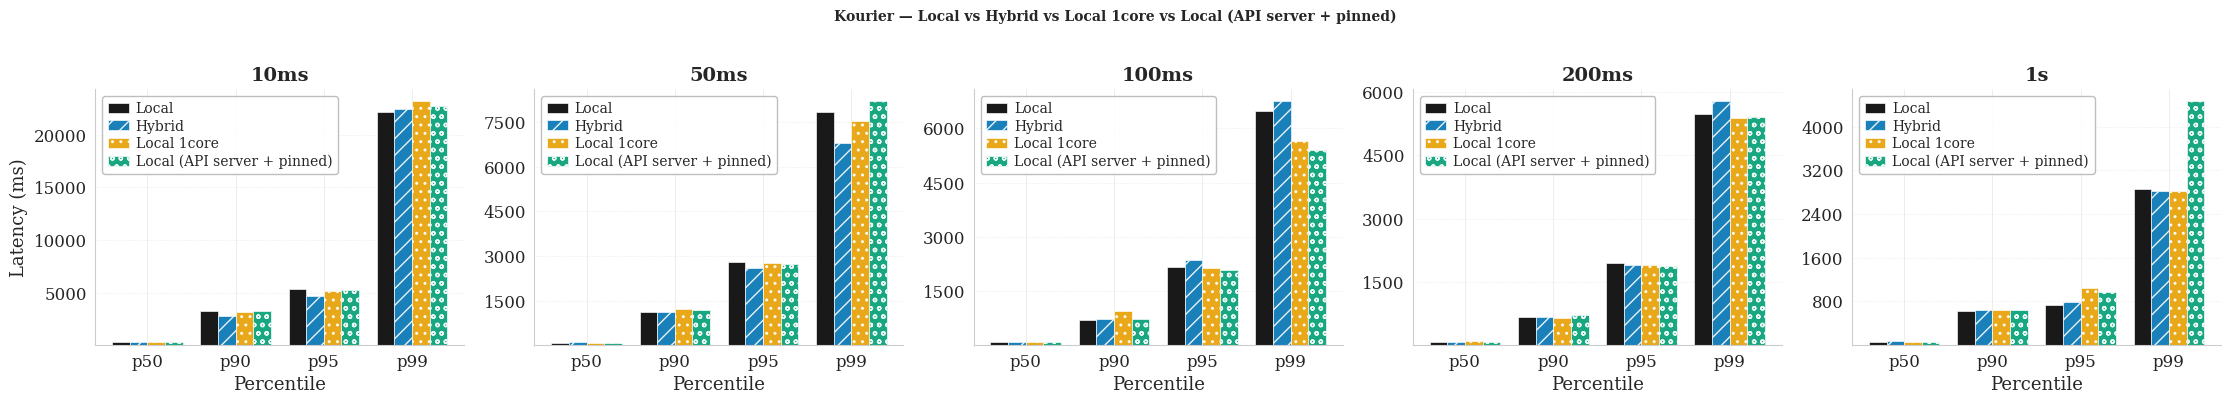

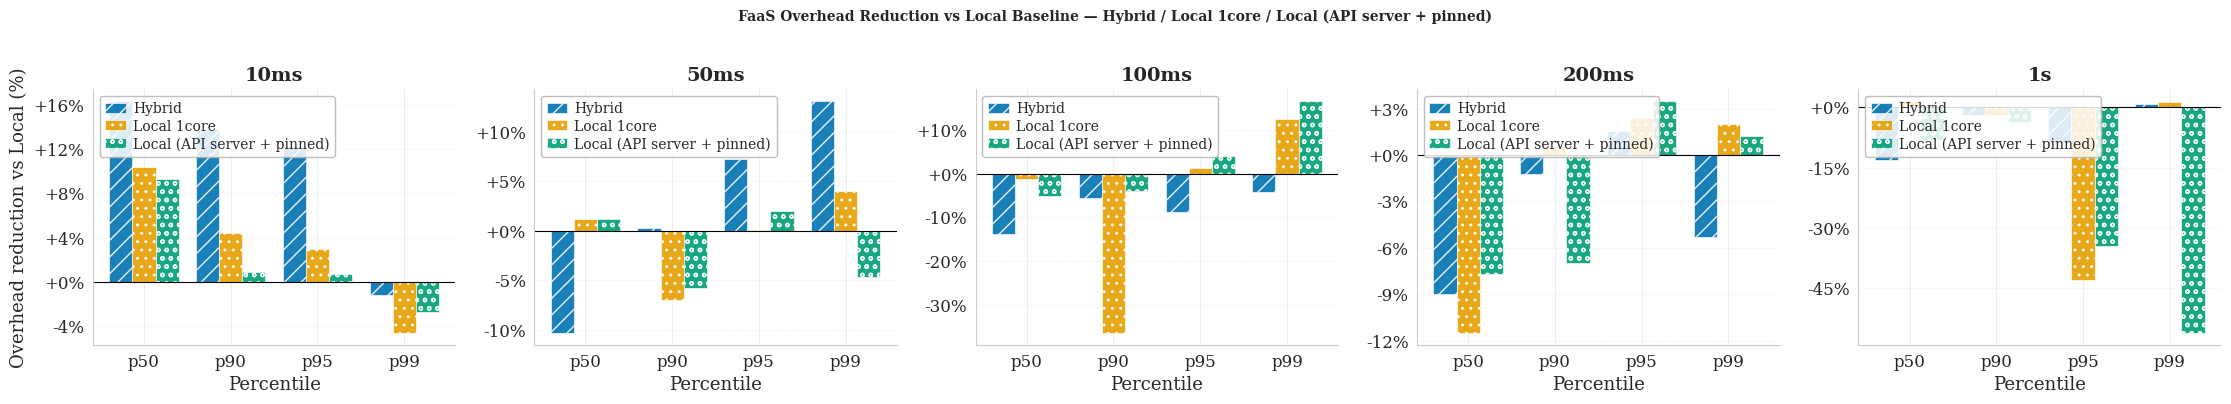

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os

# ─── STYLE ────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "font.size":          13,
    "axes.titlesize":     14,
    "axes.labelsize":     13,
    "xtick.labelsize":    12,
    "ytick.labelsize":    12,
    "legend.fontsize":    10,
    "legend.framealpha":  0.85,
    "legend.edgecolor":   "0.7",
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "grid.linewidth":     0.4,
    "grid.alpha":         0.5,
    "grid.color":         "0.75",
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
})

# ─── PALETTE ──────────────────────────────────────────────────────────
COLORS  = ["#0072B2", "#E69F00", "#009E73"]
HATCHES = ["//",      "..",      "oo"]
LABELS  = ["Hybrid", "Local 1core", "Local (API server + pinned)"]

# ─── CONFIG ───────────────────────────────────────────────────────────
DELAYS        = ["10ms", "50ms", "100ms", "200ms", "1s"]
PERCENTILES   = [50, 90, 95, 99]
PCTILE_LABELS = ["p50", "p90", "p95", "p99"]

DATA_DIR = "."

FILES = {
    "Local":           {d: os.path.join(DATA_DIR, f"kourier_df_{d}.csv")                  for d in DELAYS},
    "Hybrid":          {d: os.path.join(DATA_DIR, f"kourier_df_{d}_hybrid.csv")           for d in DELAYS},
    "Local1core":      {d: os.path.join(DATA_DIR, f"kourier_df_{d}_1core.csv")            for d in DELAYS},
    "APIserverPinned": {d: os.path.join(DATA_DIR, f"kourier_df_{d}_apiserver_pinned.csv") for d in DELAYS},
}

COMPARE_MODES = ["Hybrid", "Local1core", "APIserverPinned"]

# ─── CHARGEMENT ───────────────────────────────────────────────────────
def load_series(filepath):
    if not filepath or not os.path.exists(filepath):
        return None
    df = pd.read_csv(filepath)
    if "duration_ms" not in df.columns:
        return None
    return df["duration_ms"].dropna()

# ─── CHECK AVAILABLE FILES ────────────────────────────────────────────
available_delays = []
for d in DELAYS:
    local_ok = os.path.exists(FILES["Local"][d])
    has_any  = any(os.path.exists(FILES[m][d]) for m in COMPARE_MODES)
    if local_ok and has_any:
        available_delays.append(d)

print(f"Delays with data: {available_delays}")
if not available_delays:
    raise RuntimeError("Aucun fichier trouvé.")

# ─── FIGURE 1 : overhead absolu (ms) ──────────────────────────────────
n         = len(available_delays)
n_modes   = len(COMPARE_MODES) + 1   # Local + 3
n_pctiles = len(PERCENTILES)
x         = np.arange(n_pctiles)
bar_width = 0.8 / n_modes

fig1, axes1 = plt.subplots(1, n, figsize=(4.5 * n, 4), sharey=False)
if n == 1:
    axes1 = [axes1]

all_modes  = ["Local"] + COMPARE_MODES
all_colors = ["#000000"] + COLORS
all_hatch  = [""] + HATCHES
all_labels = ["Local"] + LABELS

for c, delay in enumerate(available_delays):
    ax = axes1[c]
    for i, mode in enumerate(all_modes):
        data = load_series(FILES[mode][delay])
        if data is None:
            continue
        vals   = [np.percentile(data, p) for p in PERCENTILES]
        offset = (i - n_modes / 2 + 0.5) * bar_width
        ax.bar(x + offset, vals, width=bar_width,
               color=all_colors[i], hatch=all_hatch[i],
               label=all_labels[i], edgecolor="white",
               linewidth=0.5, alpha=0.9)
        print(f"  [ABS] {all_labels[i]:35s} / {delay} p50={vals[0]:.1f} p99={vals[3]:.1f}")

    ax.set_title(delay, fontweight='bold')
    ax.set_xlabel("Percentile")
    ax.set_xticks(x)
    ax.set_xticklabels(PCTILE_LABELS)
    if c == 0:
        ax.set_ylabel("Latency (ms)")
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6, prune='both'))
    ax.grid(True, axis='y', linestyle=':', linewidth=0.4, color='0.75')
    ax.tick_params(direction='out', length=3, width=0.6, pad=3)
    ax.legend(loc='upper left', handlelength=1.5, borderpad=0.4,
              labelspacing=0.25, handletextpad=0.5)

fig1.suptitle("Kourier — Local vs Hybrid vs Local 1core vs Local (API server + pinned)",
              fontsize=10, fontweight='bold', y=1.01)
plt.tight_layout()
fig1.savefig("overhead_abs.pdf", dpi=300, bbox_inches="tight")
fig1.savefig("overhead_abs.png", dpi=300, bbox_inches="tight")
print("\n✓ Saved: overhead_abs.pdf / .png")

# ─── FIGURE 2 : gain relatif vs Local (%) ─────────────────────────────
# Message OSDI : "combien de % de gain par rapport à Local ?"
# Valeur positive = amélioration, négative = dégradation

fig2, axes2 = plt.subplots(1, n, figsize=(4.5 * n, 4), sharey=False)
if n == 1:
    axes2 = [axes2]

for c, delay in enumerate(available_delays):
    ax = axes2[c]

    base_data = load_series(FILES["Local"][delay])
    if base_data is None:
        continue
    base_vals = np.array([np.percentile(base_data, p) for p in PERCENTILES])

    n_cmp     = len(COMPARE_MODES)
    bar_width2 = 0.8 / n_cmp

    for i, mode in enumerate(COMPARE_MODES):
        data = load_series(FILES[mode][delay])
        if data is None:
            continue
        vals   = np.array([np.percentile(data, p) for p in PERCENTILES])
        # gain % : positif = moins d'overhead que Local
        gains  = (base_vals - vals) / base_vals * 100
        offset = (i - n_cmp / 2 + 0.5) * bar_width2

        bars = ax.bar(x + offset, gains, width=bar_width2,
                      color=COLORS[i], hatch=HATCHES[i],
                      label=LABELS[i], edgecolor="white",
                      linewidth=0.5, alpha=0.9)

        print(f"  [REL] {LABELS[i]:35s} / {delay} "
              f"p50={gains[0]:+.1f}%  p99={gains[3]:+.1f}%")

    ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
    ax.set_title(delay, fontweight='bold')
    ax.set_xlabel("Percentile")
    ax.set_xticks(x)
    ax.set_xticklabels(PCTILE_LABELS)
    if c == 0:
        ax.set_ylabel("Overhead reduction vs Local (%)")
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6, prune='both'))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:+.0f}%"))
    ax.grid(True, axis='y', linestyle=':', linewidth=0.4, color='0.75')
    ax.tick_params(direction='out', length=3, width=0.6, pad=3)
    ax.legend(loc='upper left', handlelength=1.5, borderpad=0.4,
              labelspacing=0.25, handletextpad=0.5)

fig2.suptitle(
    "FaaS Overhead Reduction vs Local Baseline — Hybrid / Local 1core / Local (API server + pinned)",
    fontsize=10, fontweight='bold', y=1.01)
plt.tight_layout()
fig2.savefig("overhead_relative.pdf", dpi=300, bbox_inches="tight")
fig2.savefig("overhead_relative.png", dpi=300, bbox_inches="tight")
print("✓ Saved: overhead_relative.pdf / .png")